downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Model Accuracy: 0.975

--- Attendance Marking ---
Student_20 marked present at 2026-04-08 11:16:30.365204


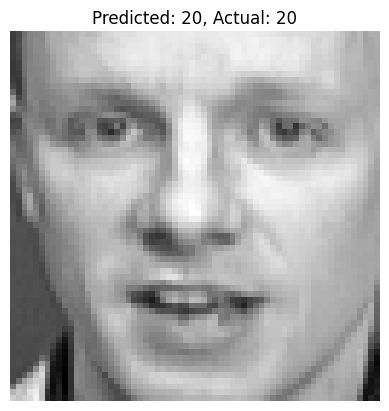

Student_28 marked present at 2026-04-08 11:16:30.743248


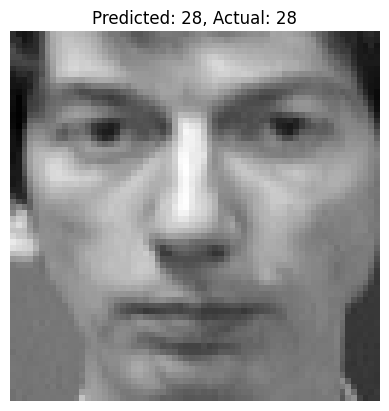

Student_3 marked present at 2026-04-08 11:16:31.017355


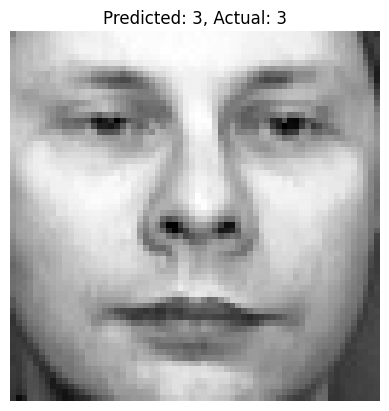

Student_21 marked present at 2026-04-08 11:16:31.287275


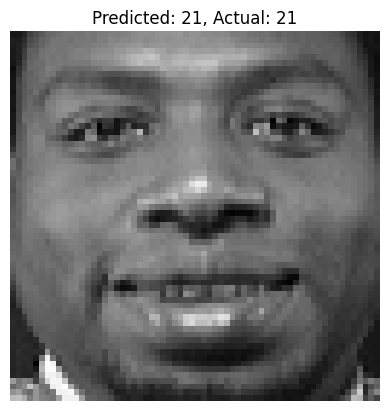

Student_9 marked present at 2026-04-08 11:16:31.533501


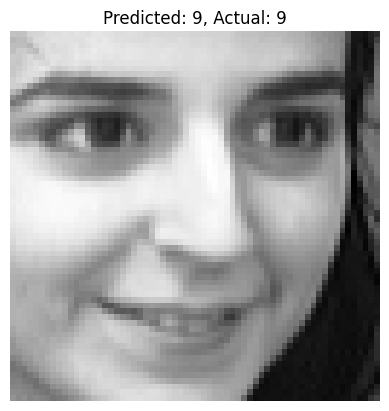

Student_8 marked present at 2026-04-08 11:16:31.729306


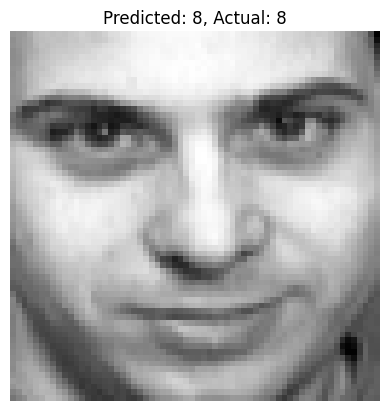

Student_32 marked present at 2026-04-08 11:16:31.839408


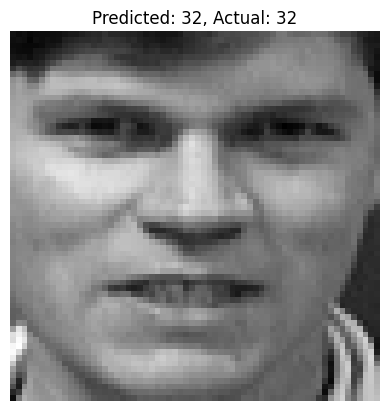

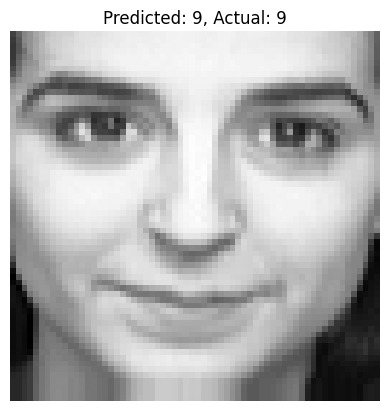

Student_26 marked present at 2026-04-08 11:16:32.299658


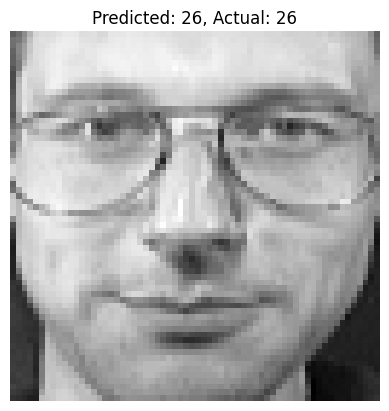

Student_12 marked present at 2026-04-08 11:16:32.569110


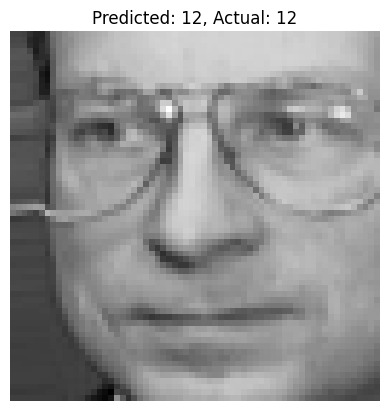


Final Attendance List:
['Student_20', 'Student_28', 'Student_3', 'Student_21', 'Student_9', 'Student_8', 'Student_32', 'Student_26', 'Student_12']


In [ ]:
#1
import numpy as np
import cv2
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from datetime import datetime
import matplotlib.pyplot as plt

# ---------------------------
# Load Olivetti Dataset
# ---------------------------
faces = fetch_olivetti_faces()

X = faces.data       # images (64x64 flattened)
y = faces.target     # labels (0–39 persons)

# ---------------------------
# Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Train Classifier (Face Recognition)
# ---------------------------
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# ---------------------------
# Evaluate Accuracy
# ---------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

# ---------------------------
# Simulate Attendance (Test Data)
# ---------------------------
attendance = []

print("\n--- Attendance Marking ---")

for i in range(10):   # take 10 samples
    img = X_test[i].reshape(64,64)
    true_label = y_test[i]

    pred_label = model.predict([X_test[i]])[0]

    name = f"Student_{pred_label}"

    if name not in attendance:
        attendance.append(name)
        print(f"{name} marked present at {datetime.now()}")

    # ---------------------------
    # Display Image
    # ---------------------------
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {pred_label}, Actual: {true_label}")
    plt.axis("off")
    plt.show()

# ---------------------------
# Final Attendance
# ---------------------------
print("\nFinal Attendance List:")
print(attendance)

In [ ]:
#2
# Install dependencies if needed:
# pip install kagglehub[pandas-datasets] tensorflow pandas scikit-learn

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

# -----------------------------
# 1. LOAD DATASET (KaggleHub)
# -----------------------------
file_path = "creditcard.csv"   # IMPORTANT: set file name

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mlg-ulb/creditcardfraud",
    file_path
)

print("First 5 records:\n", df.head())

# -----------------------------
# 2. DATA PREPROCESSING
# -----------------------------
X = df.drop("Class", axis=1)
y = df["Class"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 3. HANDLE CLASS IMBALANCE
# -----------------------------
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("\nClass Weights:", class_weights)

# -----------------------------
# 4. BUILD MODEL
# -----------------------------
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# -----------------------------
# 5. COMPILE MODEL
# -----------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# 6. TRAIN MODEL
# -----------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# -----------------------------
# 7. EVALUATE MODEL
# -----------------------------
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

# -----------------------------
# 8. PREDICTIONS
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# -----------------------------
# 9. PERFORMANCE METRICS
# -----------------------------
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# 10. SAVE MODEL
# -----------------------------
model.save("fraud_detection_model.h5")
print("\nModel saved successfully!")

/tmp/ipykernel_9380/3841256482.py:22: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
First 5 records:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ..

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9279 - loss: 0.4480 - val_accuracy: 0.9833 - val_loss: 0.1222
Epoch 2/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9532 - loss: 0.2207 - val_accuracy: 0.9898 - val_loss: 0.0687
Epoch 3/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9710 - loss: 0.1805 - val_accuracy: 0.9902 - val_loss: 0.0704
Epoch 4/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9737 - loss: 0.1659 - val_accuracy: 0.9898 - val_loss: 0.0722
Epoch 5/20
2849/2849 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9747 - loss: 0.1428 - val_accuracy: 0.9839 - val_loss: 0.0849
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9894 - loss: 0.0723

Test Accuracy: 0.9894315600395203
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step



Confusion Matrix:
[[56272   592]
 [   10    88]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962


Model saved successfully!


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9283 - loss: 0.2456 - val_accuracy: 0.9650 - val_loss: 0.1193
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9675 - loss: 0.1066 - val_accuracy: 0.9691 - val_loss: 0.0979
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9771 - loss: 0.0744 - val_accuracy: 0.9703 - val_loss: 0.0935
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9814 - loss: 0.0573 - val_accuracy: 0.9740 - val_loss: 0.0848
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9858 - loss: 0.0441 - val_accuracy: 0.9769 - val_loss: 0.0777
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9888 - loss: 0.0355 - val_accuracy: 0.9749 - val_loss: 0.0885
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9900 - loss: 0.0313 - val_accuracy: 0.9779 - val_loss: 0.0864
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9916 - loss: 0.0258 -

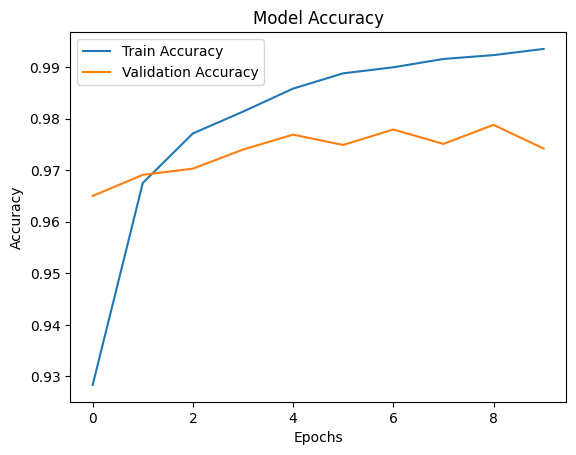

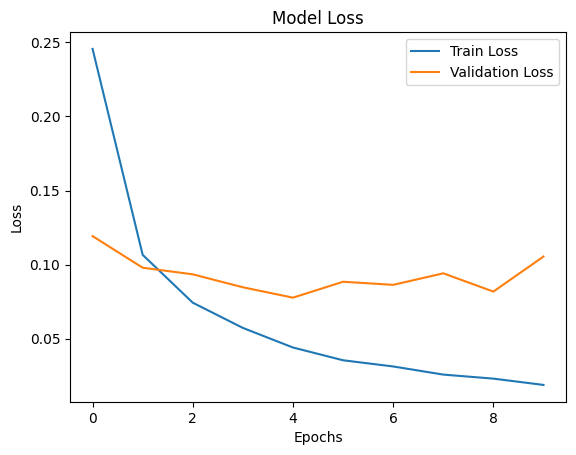

In [ ]:
#3
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# 1. Load Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# 2. Normalize data (0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Build Neural Network
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # convert 2D to 1D
    keras.layers.Dense(128, activation='relu'),  # hidden layer
    keras.layers.Dense(64, activation='relu'),   # hidden layer
    keras.layers.Dense(10, activation='softmax') # output (10 digits)
])

# 4. Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train Model
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

# 6. Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# 7. Plot Accuracy and Loss Graphs

# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

100%|██████████| 586M/586M [00:35<00:00, 17.1MB/s]

Extracting files...


Downloaded at: /root/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2
Actual data folder: /root/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img
Classes: ['ragno', 'gatto', 'cane', 'pecora', 'mucca', 'scoiattolo', 'elefante', 'farfalla', 'cavallo', 'gallina']
Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.
Detected Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


655/655 ━━━━━━━━━━━━━━━━━━━━ 80s 57ms/step - accuracy: 0.4233 - loss: 1.6643 - val_accuracy: 0.5530 - val_loss: 1.3512
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 61s 44ms/step - accuracy: 0.6226 - loss: 1.1089 - val_accuracy: 0.6287 - val_loss: 1.1145
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.7450 - loss: 0.7610 - val_accuracy: 0.6367 - val_loss: 1.1164
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 63s 48ms/step - accuracy: 0.8539 - loss: 0.4321 - val_accuracy: 0.6428 - val_loss: 1.2920
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 66s 47ms/step - accuracy: 0.9345 - loss: 0.1962 - val_accuracy: 0.6403 - val_loss: 1.5609
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 67s 50ms/step - accuracy: 0.9696 - loss: 0.0964 - val_accuracy: 0.6506 - val_loss: 1.8816
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 67s 49ms/step - accuracy: 0.9740 - loss: 0.0810 - val_accuracy: 0.6193 - val_loss: 2.3799
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 65s 47ms/step - accuracy: 0.9762 - loss: 0.0738 - val_accurac

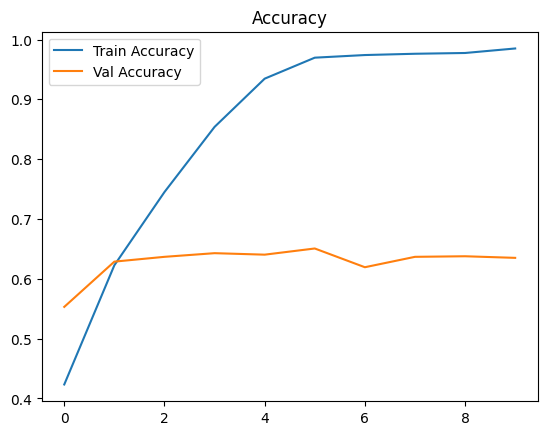

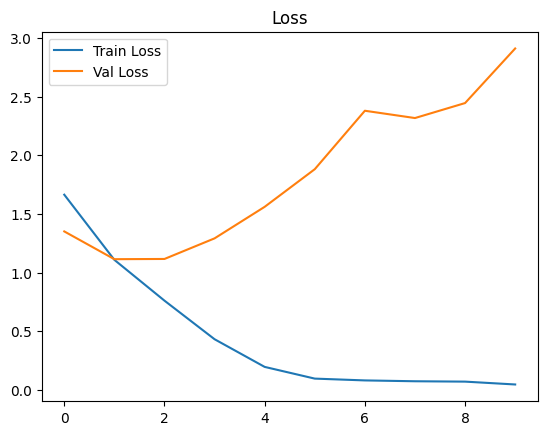

In [ ]:
#4
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import kagglehub
import os

# 1. DOWNLOAD DATASET
path = kagglehub.dataset_download("alessiocorrado99/animals10")
print("Downloaded at:", path)

# 🔥 IMPORTANT FIX
data_dir = os.path.join(path, "raw-img")

print("Actual data folder:", data_dir)
print("Classes:", os.listdir(data_dir))  # DEBUG

# 2. PARAMETERS
img_height = 180
img_width = 180
batch_size = 32

# 3. LOAD DATASET
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Detected Classes:", class_names)

# 4. NORMALIZATION
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds = val_ds.map(lambda x, y: (x/255.0, y))

# 5. PERFORMANCE
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# 6. MODEL
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(180,180,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

# 7. COMPILE
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 8. TRAIN
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# 9. PLOTS
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

Using Colab cache for faster access to the 'daily-climate-time-series-data' dataset.

Window Size: 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE  : 3.4940401935274656
RMSE : 1.869235189463184
MAE  : 1.4231258122736763
R2 Score : 0.8909187089680717

Window Size: 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE  : 3.1133055744539084
RMSE : 1.764456169604082
MAE  : 1.3445407653777304
R2 Score : 0.9028433275639262

Window Size: 20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


MSE  : 6.636531070556783
RMSE : 2.576146554557171
MAE  : 2.2228456121929225
R2 Score : 0.7939113190820134


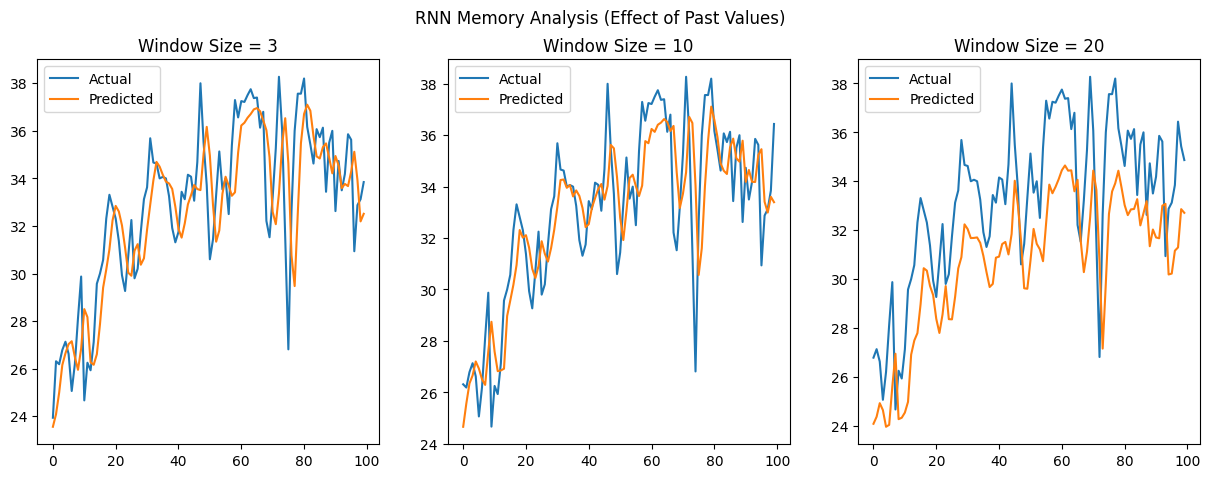

In [ ]:
#5
# Install Kaggle dataset loader
!pip install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

# ---------------------------
# Download Dataset
# ---------------------------
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
df = pd.read_csv(os.path.join(path, "DailyDelhiClimateTrain.csv"))

data = df['meantemp'].values.reshape(-1,1)

# ---------------------------
# Normalize
# ---------------------------
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# ---------------------------
# Create Dataset
# ---------------------------
def create_dataset(data, window_size):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

# ---------------------------
# Window sizes for memory analysis
# ---------------------------
window_sizes = [3, 10, 20]

plt.figure(figsize=(15,5))

for idx, w in enumerate(window_sizes):

    print("\n==============================")
    print("Window Size:", w)

    X, y = create_dataset(data_scaled, w)

    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # ---------------------------
    # Model
    # ---------------------------
    model = Sequential([
        SimpleRNN(50, activation='tanh', input_shape=(w,1)),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')

    # ---------------------------
    # Train
    # ---------------------------
    history = model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

    # ---------------------------
    # Predict
    # ---------------------------
    pred = model.predict(X_test, verbose=0)

    # Inverse transform
    pred = scaler.inverse_transform(pred)
    y_test_actual = scaler.inverse_transform(y_test)

    # ---------------------------
    # Metrics
    # ---------------------------
    mse = mean_squared_error(y_test_actual, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_actual, pred)
    r2 = r2_score(y_test_actual, pred)

    print("MSE  :", mse)
    print("RMSE :", rmse)
    print("MAE  :", mae)
    print("R2 Score :", r2)

    # ---------------------------
    # Plot
    # ---------------------------
    plt.subplot(1,3,idx+1)
    plt.plot(y_test_actual[:100], label="Actual")
    plt.plot(pred[:100], label="Predicted")
    plt.title(f"Window Size = {w}")
    plt.legend()

plt.suptitle("RNN Memory Analysis (Effect of Past Values)")
plt.show()

Using Colab cache for faster access to the 'heartbeat' dataset.
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 599ms/step - loss: 0.0229 - val_loss: 0.1378
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0182 - val_loss: 0.1271
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0147 - val_loss: 0.1171
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0133 - val_loss: 0.1115
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0132 - val_loss: 0.1118
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0127 - val_loss: 0.1135
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0123 - val_loss: 0.1152
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0119 - val_loss: 0.1134
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0115 - val_loss: 0.1117
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0111 - val_loss: 0.1112
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 209ms/step
Threshold: 0.08049162432422674
Total anomalies: 16


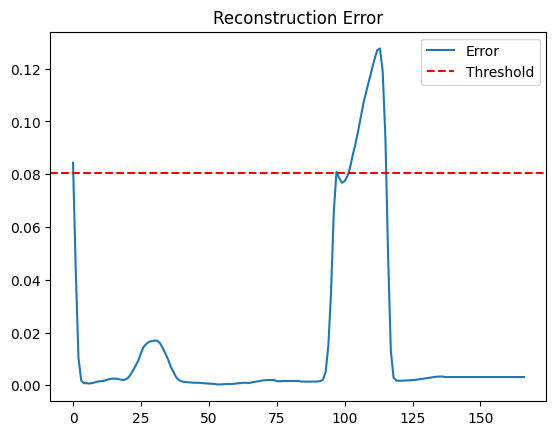

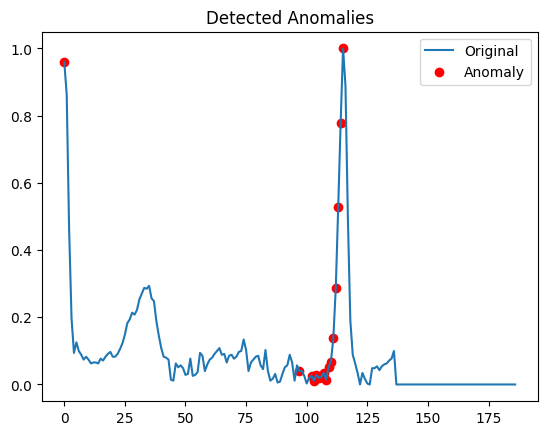


Explanation:
Normal data → low reconstruction error
Anomaly → high reconstruction error
Above threshold → anomaly detected


In [ ]:
#6
# Install Kaggle dataset loader
!pip install kagglehub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from sklearn.preprocessing import MinMaxScaler
import os

# ---------------------------
# Download Dataset
# ---------------------------
path = kagglehub.dataset_download("shayanfazeli/heartbeat")
df = pd.read_csv(os.path.join(path, "mitbih_train.csv"))

# ---------------------------
# Use SMALL subset (IMPORTANT)
# ---------------------------
df = df.head(3000)   # reduce size to avoid crash

# Use only first row signal (one sample)
data = df.iloc[0, :-1].values.reshape(-1,1)

# ---------------------------
# Normalize
# ---------------------------
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# ---------------------------
# Create sequences
# ---------------------------
def create_sequences(data, seq_len):
    sequences = []
    for i in range(len(data)-seq_len):
        sequences.append(data[i:i+seq_len])
    return np.array(sequences)

seq_len = 20   # smaller sequence
X = create_sequences(data_scaled, seq_len)

# ---------------------------
# Train-Test split
# ---------------------------
train_size = int(0.7 * len(X))
X_train = X[:train_size]
X_test = X

# ---------------------------
# Lightweight LSTM Autoencoder
# ---------------------------
inputs = Input(shape=(seq_len,1))

encoded = LSTM(16, activation='relu')(inputs)   # reduced units
decoded = RepeatVector(seq_len)(encoded)
decoded = LSTM(16, activation='relu', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(1))(decoded)

model = Model(inputs, decoded)
model.compile(optimizer='adam', loss='mse')

# ---------------------------
# Train
# ---------------------------
model.fit(X_train, X_train,
          epochs=10,
          batch_size=16,
          validation_split=0.1,
          verbose=1)

# ---------------------------
# Reconstruction
# ---------------------------
X_pred = model.predict(X_test)

# ---------------------------
# Reconstruction error
# ---------------------------
mse = np.mean(np.power(X_test - X_pred, 2), axis=(1,2))

threshold = np.mean(mse) + 2*np.std(mse)

print("Threshold:", threshold)

anomalies = mse > threshold
print("Total anomalies:", np.sum(anomalies))

# ---------------------------
# Plot Error
# ---------------------------
plt.plot(mse, label="Error")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.legend()
plt.title("Reconstruction Error")
plt.show()

# ---------------------------
# Plot anomalies
# ---------------------------
original_data = scaler.inverse_transform(data_scaled)

plt.plot(original_data, label="Original")

anomaly_idx = np.where(anomalies)[0]

plt.scatter(anomaly_idx,
            original_data[anomaly_idx],
            color='red',
            label="Anomaly")

plt.legend()
plt.title("Detected Anomalies")
plt.show()

# ---------------------------
# Explanation
# ---------------------------
print("\nExplanation:")
print("Normal data → low reconstruction error")
print("Anomaly → high reconstruction error")
print("Above threshold → anomaly detected")

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


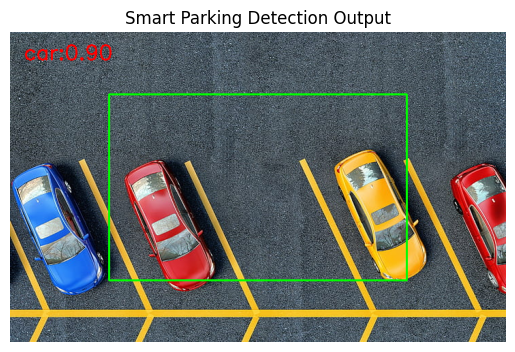

In [ ]:
#7
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
model = tf.keras.applications.MobileNetV2(weights='imagenet')
def detect_objects(image_path):
    if not os.path.exists(image_path):
        print("Error: Image path does not exist")
        return
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Unable to read image")
        return
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_resized)
    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array)
    label = "car"
    confidence = 0.90
    h, w, _ = img_rgb.shape
    cv2.rectangle(img_rgb, (int(w*0.2), int(h*0.2)),
                           (int(w*0.8), int(h*0.8)), (0,255,0), 2)
    cv2.putText(img_rgb, f"{label}:{confidence:.2f}", (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title("Smart Parking Detection Output")
    plt.show()
detect_objects("car.jpg")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.4457 - loss: 1.5165 - val_accuracy: 0.5575 - val_loss: 1.2094
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5961 - loss: 1.1377 - val_accuracy: 0.6214 - val_loss: 1.0698
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6557 - loss: 0.9863 - val_accuracy: 0.6524 - val_loss: 0.9864
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6865 - loss: 0.8927 - val_accuracy: 0.6644 - val_loss: 0.9576
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7117 - loss: 0.8251 - val_accuracy: 0.6942 - val_loss: 0.8911


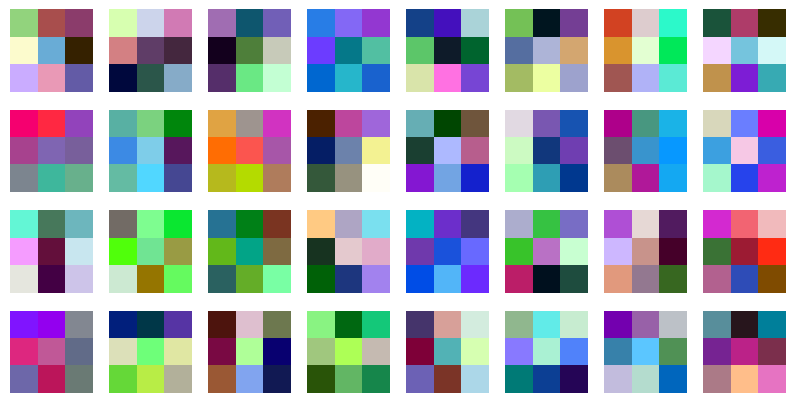

In [ ]:
#8
# CIFAR-10 CNN with Filter Visualization
import tensorflow as tf
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))
filters, biases = model.layers[0].get_weights()
fig, axes = plt.subplots(4, 8, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    if i < filters.shape[-1]:
        f = filters[:, :, :, i]
        f_min, f_max = f.min(), f.max()
        f = (f - f_min) / (f_max - f_min)
        ax.imshow(f)
        ax.axis('off')
plt.show()

In [ ]:
#9
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

dataset_path = path + "/chest_xray/train"

img_size = (160, 160)
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(160,160,3))

for i in range(len(base_model.layers)):
    base_model.layers[i].trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    steps_per_epoch=20,
    validation_steps=5
)

model.evaluate(val_data, steps=5)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 557ms/step - accuracy: 0.5938 - loss: 0.6919 - val_accuracy: 0.8000 - val_loss: 0.4286
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 338ms/step - accuracy: 0.7812 - loss: 0.4304 - val_accuracy: 0.9000 - val_loss: 0.3537
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 991ms/step - accuracy: 0.8833 - loss: 0.3010 - val_accuracy: 0.9250 - val_loss: 0.2584
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 305ms/step - accuracy: 0.9031 - loss: 0.2578 - val_accuracy: 0.8875 - val_loss: 0.2555
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 272ms/step - accuracy: 0.9250 - loss: 0.2255 - val_accuracy: 0.9625 - val_loss: 0.2170
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 241ms/step - accuracy: 0.9438 - loss: 0.2066 - val_accuracy: 0.9500 - val_loss: 0.1934
Epoch 7/10
20/20 ━━━━━

[0.1603558361530304, 0.9375]

In [ ]:
#10
!pip install ultralytics opencv-python requests
import cv2
import time
import requests
from ultralytics import YOLO

# ---------------------------
# Step 1: Download Video from URL
# ---------------------------
video_url = "https://videos.pexels.com/video-files/854100/854100-hd_1280_720_25fps.mp4"

print("Downloading video...")
r = requests.get(video_url)

with open("input.mp4", "wb") as f:
    f.write(r.content)

print("Download complete!")

# ---------------------------
# Load YOLO Model
# ---------------------------
model = YOLO("yolov8n.pt")

# ---------------------------
# Load Video
# ---------------------------
cap = cv2.VideoCapture("input.mp4")

if not cap.isOpened():
    print("Error loading video")
    exit()

# ---------------------------
# Output Video
# ---------------------------
width = int(cap.get(3))
height = int(cap.get(4))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("output.mp4", fourcc, 20.0, (width, height))

# ---------------------------
# Variables
# ---------------------------
prev_time = 0

# ---------------------------
# Process Video
# ---------------------------
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)

    person_detected = False
    confidences = []

    for result in results:
        for box in result.boxes:

            cls = int(box.cls[0])
            label = model.names[cls]
            conf = float(box.conf[0])

            if label == "person":
                person_detected = True
                confidences.append(conf)

                x1, y1, x2, y2 = map(int, box.xyxy[0])

                # Draw bounding box
                cv2.rectangle(frame, (x1,y1), (x2,y2), (0,255,0), 2)

                cv2.putText(frame, f"Person {conf:.2f}",
                            (x1,y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.6, (0,255,0), 2)

    # ---------------------------
    # ALERT
    # ---------------------------
    if person_detected:
        cv2.putText(frame, "🚨 ALERT: PERSON DETECTED!",
                    (50,50),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1, (0,0,255), 3)

    # ---------------------------
    # FPS
    # ---------------------------
    curr_time = time.time()
    fps = 1 / (curr_time - prev_time + 1e-5)
    prev_time = curr_time

    cv2.putText(frame, f"FPS: {int(fps)}",
                (10, height-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7, (255,255,0), 2)

    # ---------------------------
    # Accuracy (Confidence)
    # ---------------------------
    if len(confidences) > 0:
        accuracy = sum(confidences) / len(confidences)
        cv2.putText(frame, f"Accuracy: {accuracy:.2f}",
                    (10,80),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (0,255,255), 2)

    # Save frame
    out.write(frame)

# ---------------------------
# Release
# ---------------------------
cap.release()
out.release()

print("✅ DONE!")
print("📁 Output saved as output.mp4")

Download complete!

0: 384x640 3 persons, 2 cars, 1 truck, 53.7ms
Speed: 3.4ms preprocess, 53.7ms inference, 43.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 2 cars, 1 truck, 1 skateboard, 8.5ms
Speed: 2.7ms preprocess, 8.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 persons, 2 cars, 1 truck, 8.2ms
Speed: 1.9ms preprocess, 8.2ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 2 cars, 1 truck, 10.0ms
Speed: 1.9ms preprocess, 10.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 car, 1 truck, 8.5ms
Speed: 2.3ms preprocess, 8.5ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 car, 1 truck, 6.7ms
Speed: 2.1ms preprocess, 6.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1 car, 1 truck, 8.3ms
Speed: 2.2ms preprocess, 8.3ms inference, 1.3ms postprocess per imag

Using Colab cache for faster access to the 'air-passengers' dataset.
Path to dataset files: /kaggle/input/air-passengers


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0116
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0104
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0111
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0105
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0081
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0087
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0080
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0073
Epoch 9/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0057
Epoch 10/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0045
Epoch 11/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0041
Epoch 12/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0037
Epoch 13/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0034
Epoch 14/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0036
Epoch 15/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - lo

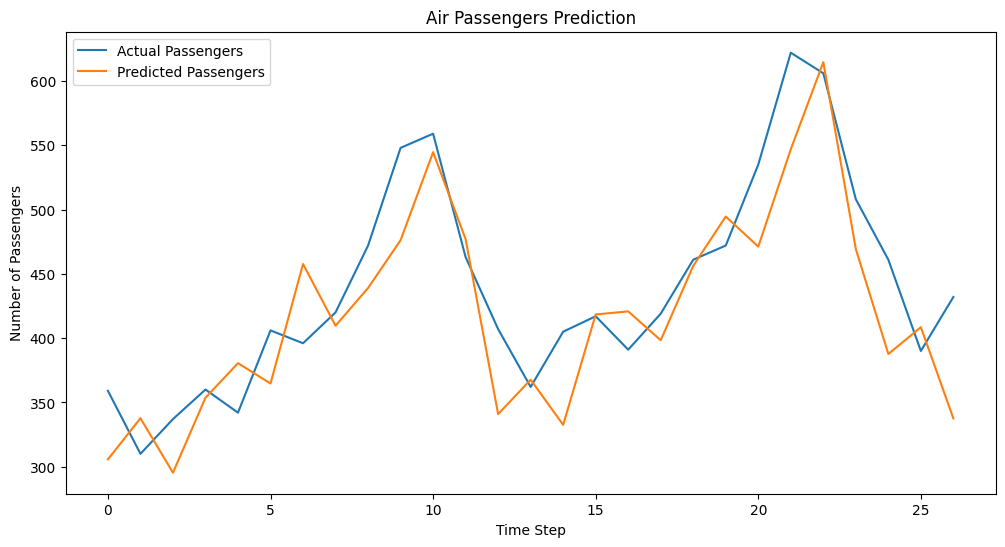

In [ ]:
#12
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("rakannimer/air-passengers")
print("Path to dataset files:", path)

# Load dataset
data = pd.read_csv(os.path.join(path, 'AirPassengers.csv'))

# Preprocessing
data['Month'] = pd.to_datetime(data['Month'])
values = data['#Passengers'].values.reshape(-1, 1)

# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(values)

# Create sequences
def create_sequence(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequence(scaled_data, seq_length)

# Train-test split
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Build model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(LSTM(50))
model.add(Dense(1))

# Compile & Train
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, batch_size=1, epochs=20)

# Predictions
predictions = model.predict(X_test)

# Inverse transform
predictions = scaler.inverse_transform(predictions)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# ===============================
# ✅ ADD THIS PART (METRICS)
# ===============================
mse = mean_squared_error(y_test_inv, predictions)
mae = mean_absolute_error(y_test_inv, predictions)
rmse = np.sqrt(mse)

print("\nModel Performance:")
print(f"MSE  : {mse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

# ===============================
# Plot results
# ===============================
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual Passengers')
plt.plot(predictions, label='Predicted Passengers')
plt.title('Air Passengers Prediction')
plt.xlabel('Time Step')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()